In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/claims_cleaned.csv', low_memory=False)
print("Loaded:", df.shape)

Loaded: (558211, 47)


In [10]:
# Group claims by provider and engineer features
provider_df = df.groupby('Provider').agg(
    total_claims          = ('ClaimID', 'count'),
    total_billed          = ('InscClaimAmtReimbursed', 'sum'),
    avg_billed            = ('InscClaimAmtReimbursed', 'mean'),
    max_billed            = ('InscClaimAmtReimbursed', 'max'),
    avg_claim_duration    = ('ClaimDuration', 'mean'),
    avg_hospital_stay     = ('HospitalStayDays', 'mean'),
    avg_deductible        = ('DeductibleAmtPaid', 'mean'),
    avg_patient_age       = ('PatientAge', 'mean'),
    inpatient_claims      = ('ClaimType', lambda x: (x == 'Inpatient').sum()),
    outpatient_claims     = ('ClaimType', lambda x: (x == 'Outpatient').sum()),
    unique_patients       = ('BeneID', 'nunique'),
    unique_physicians     = ('AttendingPhysician', 'nunique'),
    patient_death_rate    = ('PatientDied', 'mean'),
    FraudLabel            = ('FraudLabel', 'first')
).reset_index()

# Ratio features
provider_df['inpatient_ratio']      = provider_df['inpatient_claims'] / provider_df['total_claims']
provider_df['claims_per_patient']   = provider_df['total_claims'] / provider_df['unique_patients']
provider_df['billed_per_patient']   = provider_df['total_billed'] / provider_df['unique_patients']

print("Provider-level shape:", provider_df.shape)
print("Fraud rate:", round(provider_df['FraudLabel'].mean() * 100, 2), "%")

Provider-level shape: (5410, 18)
Fraud rate: 9.35 %


In [11]:
feature_cols = [
    'total_claims', 'total_billed', 'avg_billed', 'max_billed',
    'avg_claim_duration', 'avg_hospital_stay', 'avg_deductible',
    'avg_patient_age', 'inpatient_claims', 'outpatient_claims',
    'unique_patients', 'unique_physicians', 'patient_death_rate',
    'inpatient_ratio', 'claims_per_patient', 'billed_per_patient'
]

X = provider_df[feature_cols]
y = provider_df['FraudLabel']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (4328, 16)
Test size:  (1082, 16)


In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)

print("=== Random Forest ===")
print(f"AUC-ROC: {rf_auc:.4f}")
print(classification_report(y_test, rf_preds, target_names=['Legit','Fraud']))

=== Random Forest ===
AUC-ROC: 0.9548
              precision    recall  f1-score   support

       Legit       0.96      0.98      0.97       981
       Fraud       0.76      0.58      0.66       101

    accuracy                           0.94      1082
   macro avg       0.86      0.78      0.81      1082
weighted avg       0.94      0.94      0.94      1082



In [13]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)

print("=== XGBoost ===")
print(f"AUC-ROC: {xgb_auc:.4f}")
print(classification_report(y_test, xgb_preds, target_names=['Legit','Fraud']))

=== XGBoost ===
AUC-ROC: 0.9580
              precision    recall  f1-score   support

       Legit       0.95      0.98      0.97       981
       Fraud       0.76      0.53      0.63       101

    accuracy                           0.94      1082
   macro avg       0.86      0.76      0.80      1082
weighted avg       0.94      0.94      0.94      1082



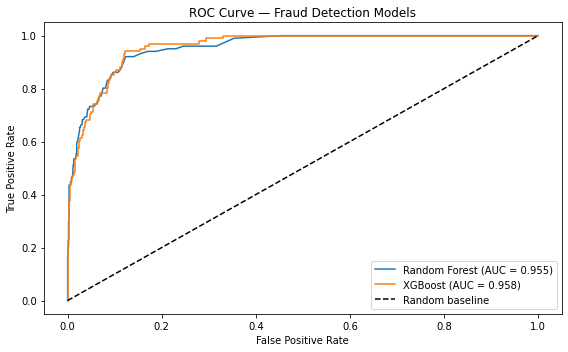

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, proba in [('Random Forest', rf_proba), ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1],'k--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Fraud Detection Models')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/roc_curve.png', dpi=150)
plt.show()

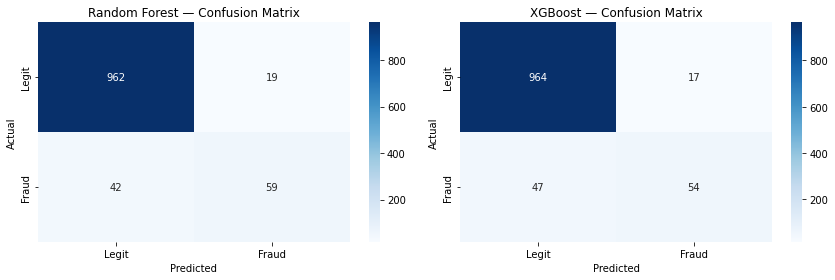

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, preds in zip(axes,
                            ['Random Forest', 'XGBoost'],
                            [rf_preds, xgb_preds]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'])
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150)
plt.show()

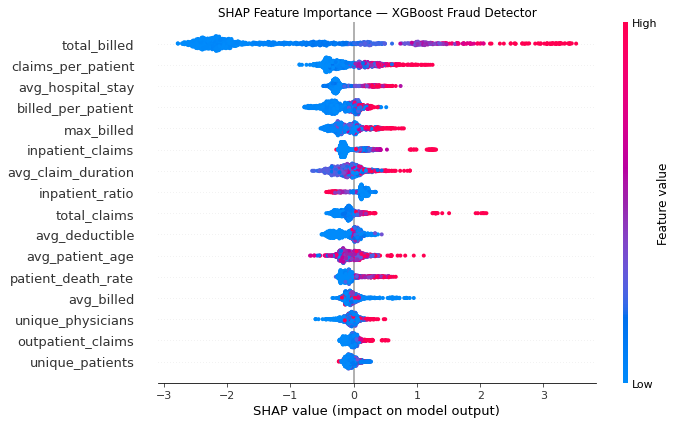

In [19]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  show=False, plot_size=(10, 6))
plt.title('SHAP Feature Importance — XGBoost Fraud Detector')
plt.tight_layout()
plt.savefig('outputs/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
import joblib
joblib.dump(xgb_model, 'outputs/fraud_xgb_model.pkl')
joblib.dump(rf, 'outputs/fraud_rf_model.pkl')
print("Models saved to outputs")

Models saved to outputs


In [25]:
import sqlite3

# --- Export 1: Provider-level summary for dashboard ---
provider_df['PotentialFraud'] = provider_df['FraudLabel'].map({1: 'Yes', 0: 'No'})

# Add fraud probability scores from XGBoost
provider_df_export = provider_df.copy()
provider_df_export['FraudProbability'] = xgb_model.predict_proba(
    provider_df[feature_cols].fillna(0)
)[:, 1].round(4)

provider_df_export.to_csv('outputs/dashboard_providers.csv', index=False)
print("Saved dashboard_providers.csv —", provider_df_export.shape)

# --- Export 2: Claims-level summary ---
claims_summary = df.groupby(['Provider', 'ClaimType']).agg(
    total_claims          = ('ClaimID', 'count'),
    total_billed          = ('InscClaimAmtReimbursed', 'sum'),
    avg_billed            = ('InscClaimAmtReimbursed', 'mean'),
    avg_claim_duration    = ('ClaimDuration', 'mean'),
    avg_hospital_stay     = ('HospitalStayDays', 'mean'),
    FraudLabel            = ('FraudLabel', 'first')
).reset_index()

claims_summary['PotentialFraud'] = claims_summary['FraudLabel'].map({1: 'Yes', 0: 'No'})
claims_summary.to_csv('outputs/dashboard_claims.csv', index=False)
print("Saved dashboard_claims.csv —", claims_summary.shape)

# --- Export 3: State-level fraud rates ---
conn = sqlite3.connect('data/fraud_detection.db')
state_fraud = pd.read_sql('''
    SELECT b.State,
           COUNT(*) AS total_claims,
           SUM(c.FraudLabel) AS fraud_claims,
           ROUND(100.0 * SUM(c.FraudLabel) / COUNT(*), 2) AS fraud_rate_pct,
           ROUND(AVG(c.InscClaimAmtReimbursed), 2) AS avg_reimbursement
    FROM claims c
    JOIN beneficiaries b ON c.BeneID = b.BeneID
    GROUP BY b.State
    HAVING total_claims > 500
    ORDER BY fraud_rate_pct DESC
''', conn)
conn.close()

state_fraud.to_csv('outputs/dashboard_states.csv', index=False)
print("Saved dashboard_states.csv —", state_fraud.shape)

# --- Export 4: SHAP feature importance ---
shap_importance = pd.DataFrame({
    'Feature': feature_cols,
    'SHAP_Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

shap_importance.to_csv('outputs/dashboard_shap.csv', index=False)
print("Saved dashboard_shap.csv —", shap_importance.shape)

Saved dashboard_providers.csv — (5410, 20)
Saved dashboard_claims.csv — (7104, 9)
Saved dashboard_states.csv — (0, 5)
Saved dashboard_shap.csv — (16, 2)


In [28]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('data/fraud_detection.db')
state_fraud = pd.read_sql('''
    SELECT CAST(b.State AS TEXT) AS State,
           COUNT(*) AS total_claims,
           SUM(c.FraudLabel) AS fraud_claims,
           ROUND(100.0 * SUM(c.FraudLabel) / COUNT(*), 2) AS fraud_rate_pct,
           ROUND(AVG(c.InscClaimAmtReimbursed), 2) AS avg_reimbursement
    FROM claims c
    JOIN beneficiaries b ON c.BeneID = b.BeneID
    GROUP BY b.State
    HAVING total_claims > 500
    ORDER BY fraud_rate_pct DESC
''', conn)
conn.close()

# Prefix with "State_" so Power BI treats it as text
state_fraud['State'] = 'State_' + state_fraud['State']
state_fraud.to_csv('outputs/dashboard_states.csv', index=False)
print("Saved:", state_fraud.shape)
print(state_fraud.head())

Saved: (0, 5)
Empty DataFrame
Columns: [State, total_claims, fraud_claims, fraud_rate_pct, avg_reimbursement]
Index: []


In [29]:
import pandas as pd

df = pd.read_csv('data/claims_cleaned.csv', low_memory=False)

# Check BeneID and State exist
print(df[['BeneID', 'State', 'FraudLabel']].head())
print("State unique values:", df['State'].nunique())

      BeneID  State  FraudLabel
0  BENE11001     39           1
1  BENE11001     39           0
2  BENE11001     39           0
3  BENE11011      1           0
4  BENE11014     45           0
State unique values: 52


In [30]:
state_fraud = df.groupby('State').agg(
    total_claims    = ('ClaimID', 'count'),
    fraud_claims    = ('FraudLabel', 'sum'),
    avg_reimbursement = ('InscClaimAmtReimbursed', 'mean')
).reset_index()

state_fraud['fraud_rate_pct'] = (state_fraud['fraud_claims'] / state_fraud['total_claims'] * 100).round(2)
state_fraud['avg_reimbursement'] = state_fraud['avg_reimbursement'].round(2)

# Filter to states with enough claims and convert to text
state_fraud = state_fraud[state_fraud['total_claims'] > 500]
state_fraud['State'] = 'State_' + state_fraud['State'].astype(str)

state_fraud = state_fraud.sort_values('fraud_rate_pct', ascending=False)
state_fraud.to_csv('outputs/dashboard_states.csv', index=False)
print("Saved:", state_fraud.shape)
print(state_fraud.head(10))

Saved: (52, 5)
       State  total_claims  fraud_claims  avg_reimbursement  fraud_rate_pct
44  State_46          3381          2124             994.84           62.82
4    State_5         51350         30335             934.18           59.07
46  State_49         14997          8613             953.83           57.43
21  State_22         13624          7798             927.83           57.24
30  State_31         15940          9112            1000.93           57.16
5    State_6          7200          3666             957.98           50.92
31  State_32          3456          1739             779.35           50.32
32  State_33         35024         17492            1020.74           49.94
38  State_39         24251         11448            1041.15           47.21
42  State_44         14418          6709             849.82           46.53


In [31]:
state_fraud = pd.read_csv('outputs/dashboard_states.csv')
print(state_fraud.dtypes)
print(state_fraud.head())

State                 object
total_claims           int64
fraud_claims           int64
avg_reimbursement    float64
fraud_rate_pct       float64
dtype: object
      State  total_claims  fraud_claims  avg_reimbursement  fraud_rate_pct
0  State_46          3381          2124             994.84           62.82
1   State_5         51350         30335             934.18           59.07
2  State_49         14997          8613             953.83           57.43
3  State_22         13624          7798             927.83           57.24
4  State_31         15940          9112            1000.93           57.16


In [32]:
state_fraud['fraud_rate_pct'] = state_fraud['fraud_rate_pct'].astype(float)
state_fraud['total_claims'] = state_fraud['total_claims'].astype(int)
state_fraud['fraud_claims'] = state_fraud['fraud_claims'].astype(int)
state_fraud['avg_reimbursement'] = state_fraud['avg_reimbursement'].astype(float)
state_fraud.to_csv('outputs/dashboard_states.csv', index=False)
print("✓ Saved with correct types")
print(state_fraud.dtypes)

✓ Saved with correct types
State                 object
total_claims           int32
fraud_claims           int32
avg_reimbursement    float64
fraud_rate_pct       float64
dtype: object


In [33]:
import pandas as pd

state_fraud = pd.read_csv('outputs/dashboard_states.csv')
print(state_fraud.dtypes)
print(state_fraud.head(3))

State                 object
total_claims           int64
fraud_claims           int64
avg_reimbursement    float64
fraud_rate_pct       float64
dtype: object
      State  total_claims  fraud_claims  avg_reimbursement  fraud_rate_pct
0  State_46          3381          2124             994.84           62.82
1   State_5         51350         30335             934.18           59.07
2  State_49         14997          8613             953.83           57.43


In [35]:
# Rebuild from scratch cleanly
df = pd.read_csv('data/claims_cleaned.csv', low_memory=False)

state_fraud = df.groupby('State').agg(
    total_claims      = ('ClaimID', 'count'),
    fraud_claims      = ('FraudLabel', 'sum'),
    avg_reimbursement = ('InscClaimAmtReimbursed', 'mean')
).reset_index()

state_fraud['fraud_rate_pct'] = (state_fraud['fraud_claims'] / state_fraud['total_claims'] * 100).round(2)
state_fraud['avg_reimbursement'] = state_fraud['avg_reimbursement'].round(2)
state_fraud = state_fraud[state_fraud['total_claims'] > 500]
state_fraud['State'] = 'State_' + state_fraud['State'].astype(str)
state_fraud = state_fraud.sort_values('fraud_rate_pct', ascending=False).reset_index(drop=True)

# Verify types before saving
print(state_fraud.dtypes)
print(state_fraud.head(3))

state_fraud.to_csv('outputs/dashboard_states.csv', index=False)
print("Done")

State                 object
total_claims           int64
fraud_claims           int64
avg_reimbursement    float64
fraud_rate_pct       float64
dtype: object
      State  total_claims  fraud_claims  avg_reimbursement  fraud_rate_pct
0  State_46          3381          2124             994.84           62.82
1   State_5         51350         30335             934.18           59.07
2  State_49         14997          8613             953.83           57.43
Done
